[*********************100%***********************]  5 of 5 completed


El vector Rt es:
Ticker         CA.PA    DHL.DE    ITX.MC      NVDA       SAN
Date                                                        
2006-12-26       NaN       NaN       NaN       NaN       NaN
2006-12-27       NaN       NaN       NaN  0.013150  0.004294
2006-12-28 -0.003262  0.005245 -0.002930 -0.007225 -0.003219
2006-12-29  0.000871 -0.004369 -0.001959 -0.006196  0.002683
2007-01-01       NaN       NaN  0.000000       NaN       NaN
...              ...       ...       ...       ...       ...
2010-12-17 -0.006336 -0.014190 -0.011282  0.005582 -0.020696
2010-12-20 -0.031514  0.001983 -0.027361 -0.004184  0.005687
2010-12-21  0.003897  0.002374  0.037453  0.038387  0.026121
2010-12-22 -0.011736  0.003551  0.004076  0.010702 -0.006467
2010-12-23  0.003300  0.004715 -0.016922 -0.007345 -0.013999

[1033 rows x 5 columns]
El nuevo Rt es:
Ticker         CA.PA    DHL.DE    ITX.MC      NVDA       SAN
Date                                                        
2006-12-28 -0.003262  0.005

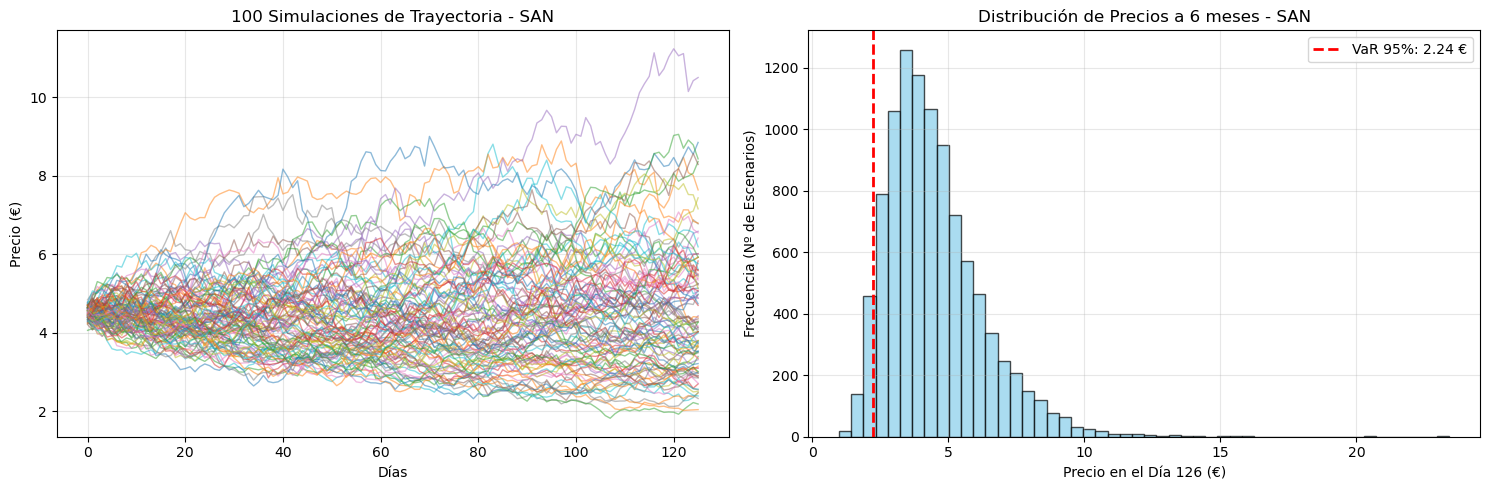

In [3]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import math as mt
import yfinance as yf
import matplotlib.pyplot as plt
import statistics

datos=yf.download(["SAN","DHL.DE","NVDA","ITX.MC","CA.PA"], start="2006-12-25", end="2010-12-25")
                   #SAN - banco santander
                   #NVDA - NVIDIA
                   #ITX.MC - inditex
                  #CA.PA - Carrefour
#fechas en la que está incluida las crisis del 2008

# --- 1. PREPARACIÓN DE DATOS (Vectorizada) ---
precios_cierre = datos['Close']

# Calculamos todos los retornos diarios de golpe para las 5 empresas
Rt = np.log(precios_cierre / precios_cierre.shift(1)) #con shift(1) se desplaza en uno todo Rt y se pone NAN como primer valor y se elimina el último, sale del rango.
#print('El vector Rt es:')
#print(Rt)
# Eliminamos con dropna() cualquier fila que tenga al menos un NAN
Rt = Rt.dropna()
#print('El nuevo Rt es:')
#print(Rt)

media = Rt.mean() #axis{index (0), columns (1)} por defecto actua sobre "index" - filas
volatilidad = Rt.std() #calculamos la desviación estándar de los elementos de la fila

# --- 2. CONFIGURACIÓN DEL SIMULADOR MONTE CARLO ---
dias_simulacion = 126
num_escenarios = 10000

# Creamos un diccionario para guardar el VaR y los resultados de cada empresa
resultados_finales = {}

print("\n--- INICIANDO SIMULACIÓN MONTE CARLO ---")

# Iteramos sobre cada ticker (SAN, NVDA, etc.)
for empresa in precios_cierre.columns:  #bucle en el que vamos cambiando de empresa
    
    # Extraemos parámetros de esta empresa específica
    mu = media[empresa]
    sigma = volatilidad[empresa]
    
    # St1: El precio inicial de partida es el ÚLTIMO precio histórico de esa empresa
    S0 = precios_cierre[empresa].iloc[-1] #[-1] - es el último elemento, [-2] - es el penúltimo, [0] - es la primera fila
    
    # Generamos la matriz Z: 126 días x 10.000 escenarios. Media 0, Volatilidad 1
    Z = np.random.normal(0, 1, size=(dias_simulacion, num_escenarios))
    # media=0, desviación=1, size - tamaño de Z
    
    # Calculamos el "paso" diario de la fórmula del Movimiento Browniano para toda la matriz
    paso_diario = (mu - (sigma**2) / 2) + sigma * Z
    
    # Suma acumulada: sumamos los pasos a lo largo del eje del tiempo (axis=0)
    exponente_acumulado = np.cumsum(paso_diario, axis=0) 

    #ejemplo sencillo de cumsum::: [1,2,3] -> [1,3,6]
    #axis=0 - solo para asegurar que la operación opere sobre las filas
    
    # Matriz final de precios: Calculamos todos los caminos simultáneamente
    S_trayectorias = S0 * np.exp(exponente_acumulado)
    
    # Extraemos solo la última fila (el día 126) de los 10.000 escenarios
    precios_dia_126 = S_trayectorias[-1, :]
    
    # Guardamos los resultados de los 10.000 finales posibles
    resultados_finales[empresa] = precios_dia_126
    
    print(f"Simulados {num_escenarios} escenarios para {empresa} con éxito.")

    # --- 3. ANÁLISIS DE RIESGO Y VISUALIZACIÓN ---
empresa_viz = "SAN"

# 1. Recuperar los datos simulados de la empresa que queremos visualizar
precios_finales = resultados_finales[empresa_viz]

# 2. Calcular el VaR al 95% (El percentil 5)
# Esto significa que ordenamos los 10.000 precios de menor a mayor y cogemos el que está en la posición 5%
#El 95% de las veces el precio estará por encima de este valor, y el 5% de las veces el precio estará por encima de ese valor
var_95_precio = np.percentile(precios_finales, 5)

# Calculamos cuánto dinero se perdería respecto al precio inicial
precio_inicial = precios_cierre[empresa_viz].iloc[-1]
perdida_maxima = precio_inicial - var_95_precio

print(f"\n--- REPORTE DE RIESGO: {empresa_viz} ---")
print(f"Precio inicial: {precio_inicial:.2f} €") #.2f - para que solo salgan dos decimales (.nf - solo salen "n" decimales)
print(f"VaR 95% (Precio de corte): {var_95_precio:.2f} €")
print(f"Pérdida máxima esperada (95% de confianza): {perdida_maxima:.2f} €")

# 3. Configurar la figura con dos subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

#.subplots(filas,columnas,tamaño de la ventana)

# --- GRÁFICO 1: Trayectorias (Simulamos las rutas de nuevo rápido solo para el gráfico) ---
mu_viz = media[empresa_viz]
sigma_viz = volatilidad[empresa_viz]
Z_viz = np.random.normal(0, 1, size=(dias_simulacion, 100)) # Solo 100 escenarios
S_rutas_viz = precio_inicial * np.exp(np.cumsum((mu_viz - (sigma_viz**2) / 2) + sigma_viz * Z_viz, axis=0))

ax1.plot(S_rutas_viz, alpha=0.5, linewidth=1)
ax1.set_title(f'100 Simulaciones de Trayectoria - {empresa_viz}')
ax1.set_xlabel('Días')
ax1.set_ylabel('Precio (€)')
ax1.grid(True, alpha=0.3)

# --- GRÁFICO 2: Histograma y VaR ---
ax2.hist(precios_finales, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
# Dibujamos la línea del VaR
ax2.axvline(var_95_precio, color='red', linestyle='dashed', linewidth=2, 
            label=f'VaR 95%: {var_95_precio:.2f} €') 
#axvline(var_95_precio,...) - en que punto del eje x poner la línea vertical

ax2.set_title(f'Distribución de Precios a 6 meses - {empresa_viz}')
ax2.set_xlabel('Precio en el Día 126 (€)')
ax2.set_ylabel('Frecuencia (Nº de Escenarios)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout() #ajusta automáticamente los espacios entre las gráficas para que no se solapen ni se vean apretadas
plt.show() #muestra la gráfica en la pantalla


######################realmente aquí acabaría este miniproyecto.

# ==============================================================================
# --- 0. DATOS DE ENTRADA REALES (Sustituye esto por tus variables reales) ---
# ==============================================================================
# Asumiremos que tienes estas variables de tu simulación:
# 1. 'initial_price_real': El precio inicial de la acción.
# 2. 'simulation_paths_matrix': Una matriz NumPy (días, escenarios) con los precios simulados.
# 3. 'var_95_value_real': El valor numérico de tu VaR calculado al 95%.

# --- DATOS DE EJEMPLO PARA QUE EL CÓDIGO FUNCIONE (Sustituye con los reales) ---
# Vamos a generar datos de ejemplo que se parezcan visualmente
np.random.seed(42)  # Para reproducibilidad
dias_simulados = 126 # 6 meses
num_escenarios_totales = 10000
escenarios_a_graficar = 100 # Solo graficamos una muestra para no colapsar la pantalla
precio_inicial_real = 100
annual_mu = 0.08  # 8% retorno anual
annual_sigma = 0.2 # 20% volatilidad anual

dt = 1/252 # Paso de tiempo diario
mu_diaria = annual_mu * dt
sigma_diaria = annual_sigma * np.sqrt(dt)

# Simulación simplificada (Geometric Brownian Motion)
drift = (mu_diaria - 0.5 * sigma_diaria**2)
vol = sigma_diaria
returns = np.random.normal(drift, vol, (dias_simulados, num_escenarios_totales))
simulation_paths_matrix = np.zeros((dias_simulados + 1, num_escenarios_totales))
simulation_paths_matrix[0, :] = precio_inicial_real
simulation_paths_matrix[1:, :] = precio_inicial_real * np.exp(np.cumsum(returns, axis=0))

# Cálculo del VaR real (5to percentil de los precios finales)
final_prices = simulation_paths_matrix[-1, :]
var_95_value_real = np.percentile(final_prices, 5)
# --- FIN DE DATOS DE EJEMPLO ---

# ==============================================================================
# --- 1. CONFIGURACIÓN DEL GRÁFICO (El aspecto visual) ---
# ==============================================================================

# Crear una figura nueva
fig = go.Figure()

# Aplicar plantilla de dark mode para el aspecto limpio
fig.update_layout(template="plotly_dark")

# 1. PUNTO DE INICIO (El punto azul en t=0)
fig.add_trace(go.Scatter(
    x=[0],
    y=[precio_inicial_real],
    mode='markers',
    marker=dict(size=12, color='dodgerblue', line=dict(width=2, color='white')),
    name='Punto de Inicio',
    showlegend=False # Es obvio, no lo ponemos en la leyenda
))

# 2. RUTAS DE SIMULACIÓN ("Espaguetis" grises)
# Para rendimiento y claridad visual, solo graficamos una muestra.
indices_muestra = np.random.choice(num_escenarios_totales, escenarios_a_graficar, replace=False)
for i in indices_muestra:
    fig.add_trace(go.Scatter(
        x=list(range(dias_simulados + 1)),
        y=simulation_paths_matrix[:, i],
        mode='lines',
        line=dict(color='rgba(150, 150, 150, 0.2)', width=1),
        name='Ruta Individual', # Usamos nombre compartido para el grupo de leyenda
        legendgroup='Normal', # Agrupa las rutas para usar una sola entrada en la leyenda
        showlegend=False, # No queremos 100 entradas individuales
        opacity=0.5
    ))

# 3. LÍNEA VaR (Línea discontinua roja)
fig.add_trace(go.Scatter(
    x=[0, dias_simulados],
    y=[var_95_value_real, var_95_value_real],
    mode='lines',
    line=dict(color='red', width=2.5, dash='dash'),
    name='Línea de Riesgo',
    legendgroup='VaR',
    showlegend=False # Usamos una entrada de leyenda personalizada
))

# 4. TEXTO VaR (Al final de la línea discontinua, abajo)
formatted_var_text = f"VaR 95%: ${var_95_value_real:.2f}"
fig.add_trace(go.Scatter(
    x=[dias_simulados],
    y=[var_95_value_real],
    mode='text+markers', # Usamos markers para posicionar el texto, luego los ocultamos
    text=[formatted_var_text],
    textposition='bottom center', # Posicionamos el texto debajo y al centro del último punto
    textfont=dict(color='red', size=14, family="Arial, sans-serif"),
    marker=dict(color='rgba(0,0,0,0)', size=0), # Marker oculto
    showlegend=False
))

# 5. ENTRADAS DE LEYENDA PERSONALIZADAS (Para imitar el aspecto)
# Entrada para "Normal" (Gris con punto)
fig.add_trace(go.Scatter(
    x=[None], y=[None], # Puntos invisibles, solo para leyenda
    mode='markers',
    marker=dict(size=10, color='grey'),
    name='Normal',
    showlegend=True
))

# Entrada para "VaR 95%" (Roja con cuadro/línea)
# No hay una forma directa de hacer un cuadro de leyenda rojo puro con go.Scatter,
# así que usamos una línea roja muy ancha o un punto rojo. Usaremos el cuadro de leyenda por defecto.
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='lines+markers',
    marker=dict(color='red', size=10, symbol='square'),
    line=dict(color='red', width=0),
    name='VaR 95%',
    showlegend=True
))

# ==============================================================================
# --- 2. DISEÑO DEL LAYOUT FINAL (Títulos y Ejes) ---
# ==============================================================================
fig.update_layout(
    # Título principal exacto
    title={
        'text': "Simulador de Precios Monte Carlo",
        'font': {'size': 24},
        'x': 0.05,
        'y': 0.95
    },
    
    # Eje Y (con flecha)
    yaxis=dict(
        title=dict(
            text="Precio ($) &uarr;", # Flecha hacia arriba con entidad HTML
            font={'size': 16}
        ),
        showgrid=True, gridcolor='rgba(255,255,255,0.1)',
        zeroline=False
    ),
    
    # Eje X (con flecha)
    xaxis=dict(
        title=dict(
            text="Días de Negociación &rarr;", # Flecha hacia la derecha
            font={'size': 16}
        ),
        showgrid=True, gridcolor='rgba(255,255,255,0.1)',
        tickvals=[0, 20, 40, 60, 80, 100, 120] # Marcas de ticks exactas
    ),
    
    # Configuración de la leyenda
    legend=dict(
        yanchor="top",
        y=0.9,
        xanchor="left",
        x=0.05,
        bgcolor="rgba(0,0,0,0)" # Fondo de leyenda transparente
    ),
    
    margin=dict(l=80, r=40, t=100, b=80), # Márgenes limpios
)

# Mostrar el gráfico
# Si estás en un entorno como Jupyter, se mostrará automáticamente.
# Si estás ejecutando un script de Python normal, usa `fig.show()`.
fig.show()